In [32]:
import numpy as np
import matplotlib.pyplot as plt


In [72]:
parameters = '''H	0.2772	1.7504	3.6516	95.99	
He	0.2425	2.0870	2.1843	40.67	
Li	0.3266	2.3073	1.2711	70.21	
Be	0.3964	2.8811	3.3497	114.51	
B	0.3121	2.6366	2.7079	152.36	
C_2 0.2808	3.0548	2.2348	429.69	
C_3	0.2455	3.0189	1.8219	184.28	
N_2	0.2996	3.0200	2.6454	720.18	
N_3	0.2743	2.9432	2.4667	482.54	
O	0.2577	2.7407	2.3650	405.57	
F	0.2791	2.5863	1.5062	218.45	
Ne	0.2378	2.5307	1.8233	174.81	
Na	0.2592	2.5679	1.3974	181.70	
Mg	0.3837	2.9613	3.3515	263.02	
Al	0.3013	3.2377	3.0102	228.10	
Si	0.3202	3.2749	3.1629	359.43	
P	0.3399	3.7491	3.2554	3222.12	
S	0.3215	3.6718	2.9539	2144.49	
Cl	0.3071	3.4180	3.0368	2072.46	
Ar	0.2752	3.3306	2.6598	1357.42	
K	0.2264	2.9736	4.0877	1406.65	
Ca	0.4015	3.4464	4.1275	1058.36	
Sc	0.9388	4.5955	9.7282	11498.73	
Ti	0.6048	3.5334	8.5322	3361.33	
V	0.3678	3.0680	7.2344	2095.91	
Cr	0.2848	2.8393	5.3605	1049.31	
Mn	0.3550	3.0550	3.7180	966.27	
Fe	0.4406	3.2628	3.6408	1571.36	
Co	0.4124	3.2622	3.4961	1183.59	
Ni	0.3139	2.7490	3.5108	787.76	
Cu	0.3345	2.9097	3.0537	563.93	
Zn	0.3391	2.9024	3.0261	592.91	
Ga	0.3146	3.3924	3.1735	430.82	
Ge	0.3327	3.2804	3.1773	812.57	
As	0.4040	3.8757	3.8357	4533.53	
Se	0.3343	3.8562	3.1109	3440.92	
Br	0.3242	3.7067	3.2122	3859.82	
Kr	0.2920	3.6457	2.8263	2729.60
Rb	0.2677	3.4421	2.4120	1864.19
Sr	0.3446	3.5590	1.8940	1175.73
Y	1.0038	5.7293	11.2061	32141.18
Zr	0.6146	5.0750	6.8210	27655.14
Nb	0.4244	3.7156	7.2367	2864.20
Mo	0.4882	3.6853	3.9010	3563.45
Tc	0.4439	3.6987	4.0857	3266.43
Ru	0.4736	3.7826	4.0450	3967.23
Rh	0.4039	3.4706	3.4813	2233.82
Pd	0.3188	3.3433	3.0487	1393.49
Ag	0.2948	3.1186	2.7795	1315.09
Cd	0.3012	3.0853	2.8673	1311.47
In	0.3351	3.5452	3.3339	1460.56
Sn	0.3134	3.2997	3.0086	1662.99
Sb	0.4081	4.1277	3.9919	8089.97
Te	0.3585	4.1795	3.4209	6887.05
I	0.3574	4.0988	3.5649	8799.32
Xe	0.3134	4.0387	3.0288	6136.50
Cs	0.2872	3.8468	2.2620	3757.31
Ba	0.3788	4.0368	1.3837	2561.18
La	1.0851	6.1365	12.1710	66580.83
Hf	0.5577	5.2130	6.0791	27593.76
Ta	0.5308	4.7637	5.7661	15364.65
W	0.3926	3.6018	3.6366	2734.50
Re	0.5351	3.9552	4.2410	4801.82
Os	0.4701	4.0278	4.1348	5685.94
Ir	0.3661	3.6123	3.4213	2786.00
Pt	0.3411	3.6066	3.2486	2699.79
Au	0.3164	3.3822	2.9588	2282.60
Hg	0.3047	3.3750	2.9381	2476.79
Tl	0.2802	3.3964	2.7711	2988.70
Pb	0.2682	3.2481	2.5816	2506.63
Bi	0.3876	4.1225	3.7850	8916.84
Po	0.3679	4.2313	3.5381	8694.22
At	0.3680	4.2455	3.6985	11821.61
Rn	0.3195	4.1784	3.0551	8410.64'''

parameters_dict = {line.split()[0]: {'s': float(line.split()[1]),
                                      'beta': float(line.split()[2]),
                                      'R': float(line.split()[3]),
                                      'C6': float(line.split()[4])} for line in parameters.splitlines()}

# Save parameters_dict to a JSON file
import json
with open('gnp_parameters.json', 'w') as f:
    json.dump(parameters_dict, f, indent=4)

In [73]:
import os
os.getcwd()

'c:\\Users\\flopes\\Documents\\PRs\\flames'

In [55]:
from dataclasses import dataclass

@dataclass(slots=True)
class TypeParameters:
    """Class for storing element parameters."""
    s: float
    beta: float
    R: float
    C6: float

@dataclass(slots=True)
class GNPParameters:
    """Class for storing GNP parameters for multiple elements."""
    atom_type: dict[str, TypeParameters]

    @classmethod
    def from_dict(cls, parameters_dict: dict[str, dict[str, float]]) -> 'GNPParameters':
        """Create GNPParameters from a dictionary."""
        atom_types = {element: TypeParameters(**params) for element, params in parameters_dict.items()}
        return cls(atom_type=atom_types)


def mix_parameters(
        par1: TypeParameters,
        par2: TypeParameters
        ) -> TypeParameters:
    """
    Mix parameters of two elements using geometric mean for s and beta and arithmetic mean for R and C6.
    
    Parameters
    ----------
    par1 : TypeParameters
        Parameters of the first element.
    par2 : TypeParameters
        Parameters of the second element.

    Returns
    -------
    TypeParameters
        Mixed parameters of the two elements.
    """
    # Aritimetric means
    mixed_s = (par1.s + par2.s) / 2
    mixed_beta = (par1.beta + par2.beta) / 2

    # Geometric means
    mixed_C6 = float(np.sqrt(par1.C6 * par2.C6))
    mixed_R = float(np.sqrt(par1.R * par2.R))

    return TypeParameters(s=mixed_s, beta=mixed_beta, R=mixed_R, C6=mixed_C6)

par = GNPParameters.from_dict(parameters_dict)

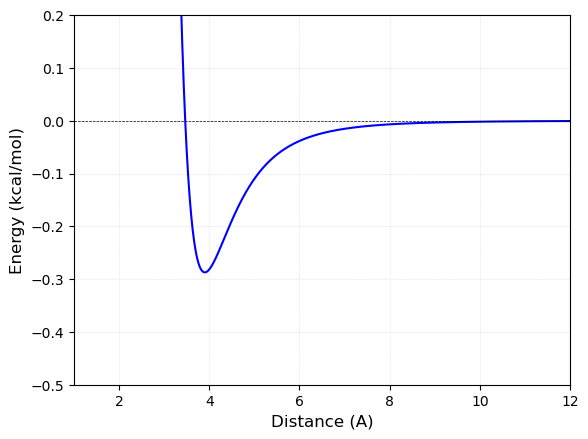

In [56]:

def gnp(
    r: float | np.ndarray,
    params: TypeParameters
        ) -> float | np.ndarray:
    """
    Calculate the generalized nonbonded potential (GNP) for a given distance r.

    Parameters
    ----------
    r : float | np.ndarray
        Distance between particles.
    beta : float
        Inverse temperature (1/kT).
    s : float
        Scaling factor for the potential.
    c6 : float
        Coefficient for the attractive term.
    R : float
        Characteristic distance for the repulsive term.

    Returns
    -------
    float | np.ndarray
        The energy value of the GNP at distance r.
    """
    # Pauli Repulsion (PR)
    E_pr = np.exp(- (r - params.beta) / params.s)

    # London Dispersion (LD)
    E_ld = - params.C6 / (params.R ** 6 + r ** 6)

    # Total potential
    potential = E_pr + E_ld

    return potential

r = np.linspace(1, 12, 1000)  # Distance range from 0.1 to 5

test = mix_parameters(par.atom_type['C_2'], par.atom_type['C_2'])

E = gnp(r, test) * 4.184

fig, ax = plt.subplots()

ax.plot(r, E, label='GNP Potential', color='blue')

ax.set_xlim(1, 12)

ax.set_ylim(-0.5, 0.2)

ax.set_xlabel('Distance (A)', fontsize=12)
ax.set_ylabel('Energy (kcal/mol)', fontsize=12)

ax.axhline(0, color='black', lw=0.5, ls='--')

ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.3)

In [59]:
from ase.units import kcal, mol

(kcal / mol)

0.04336410390059322

In [62]:
import numpy as np
from ase import units
from ase.calculators.calculator import Calculator, all_changes
from numba import njit
from vesin import NeighborList
from dataclasses import dataclass

# --- User's Dataclass Definitions ---
@dataclass(slots=True)
class TypeParameters:
    """Class for storing element parameters."""
    s: float
    beta: float
    R: float
    C6: float

@dataclass(slots=True)
class GNPParameters:
    """Class for storing GNP parameters for multiple elements."""
    atom_type: dict[str, TypeParameters]

    @classmethod
    def from_dict(cls, parameters_dict: dict[str, dict[str, float]]) -> 'GNPParameters':
        """Create GNPParameters from a dictionary."""
        atom_types = {element: TypeParameters(**params) for element, params in parameters_dict.items()}
        return cls(atom_type=atom_types)

# --- Numba JIT Kernel ---
@njit(fastmath=True, parallel=False, cache=True)
def compute_gnp_numba(
    i_idx, j_idx, distances, s_vec, beta_vec, r_vec, c6_vec, cutoff, shifted
) -> tuple[float, np.ndarray]:
    total_energy = 0.0
    energies = np.zeros(len(s_vec))

    # Loop over all interacting pairs
    for k in range(len(i_idx)):
        i = i_idx[k]
        j = j_idx[k]
        r = distances[k]

        # Mixing rules (Arithmetic for s/beta, Geometric for R/C6)
        s_mix = (s_vec[i] + s_vec[j]) / 2.0
        beta_mix = (beta_vec[i] + beta_vec[j]) / 2.0
        r_mix = np.sqrt(r_vec[i] * r_vec[j])
        c6_mix = np.sqrt(c6_vec[i] * c6_vec[j])

        # Fast math for R^6 and r^6
        r3 = r * r * r
        r6 = r3 * r3
        R3 = r_mix * r_mix * r_mix
        R6 = R3 * R3

        # Energy calculation
        e_pr = np.exp(-(r - beta_mix) / s_mix)
        e_ld = -c6_mix / (R6 + r6)
        u = e_pr + e_ld

        if shifted:
            # Calculate the potential exactly at the cutoff distance
            e_pr_shift = np.exp(-(cutoff - beta_mix) / s_mix)
            rc3 = cutoff * cutoff * cutoff
            rc6 = rc3 * rc3
            e_ld_shift = -c6_mix / (R6 + rc6)
            
            u_shift = e_pr_shift + e_ld_shift
            u -= u_shift

        # Divide by 2 because the neighbor list includes both i->j and j->i
        u_half = u / 2.0
        total_energy += u_half
        energies[i] += u_half

    return total_energy, energies


# --- ASE Calculator ---
class CustomGNP(Calculator):
    """
    Custom Generalized Nonbonded Potential (GNP) calculator based on the ASE interface.
    
    Energy is evaluated as:
    E = exp(-(r - beta) / s) - C6 / (R^6 + r^6)
    
    The internal calculation expects/computes kcal/mol but returns eV to comply
    with standard ASE units.
    """

    implemented_properties = ["energy", "energies", "free_energy"]
    default_parameters = {
        "vdw_cutoff": 12.0,
        "shifted": True,
    }
    nolabel = True

    def __init__(self, gnp_parameters: GNPParameters, **kwargs):
        """
        Parameters
        ----------
        gnp_parameters : GNPParameters
            Dataclass instance containing the GNP parameters for elements.
        vdw_cutoff : float, optional
            Cutoff distance for the nonbonded interactions. Default is 12.0 Angstroms.
        shifted : bool, optional
            Whether to shift the potential to zero at the cutoff. Default is True.
        """
        Calculator.__init__(self, **kwargs)
        
        self.gnp_params: GNPParameters = gnp_parameters
        self.vdw_cutoff = kwargs.get("vdw_cutoff", 12.0)
        self.shifted = kwargs.get("shifted", True)

    def calculate(
        self,
        atoms=None,
        properties=None,
        system_changes=all_changes,
    ):
        if properties is None:
            properties = self.implemented_properties

        Calculator.calculate(self, atoms, properties, system_changes)
        np.seterr(invalid="ignore")

        # Use custom atom labels if available, otherwise fall back to chemical symbols
        if "labels" in self.atoms.arrays:  # type: ignore
            labels = [
                self.atoms.symbols[i] if str(label) == "0" else label  # type: ignore
                for i, label in enumerate(self.atoms.arrays["labels"])  # type: ignore
            ]
        else:
            labels = self.atoms.get_chemical_symbols()  # type: ignore

        # ---------------------------------------------------------------------
        # Dataclass Unpacking for Numba
        # We must extract the dataclass properties into flat NumPy arrays 
        # so the C-compiled Numba kernel can parse them natively.
        # ---------------------------------------------------------------------
        s_vec = np.array([self.gnp_params.atom_type[sym].s for sym in labels], dtype=np.float64)
        beta_vec = np.array([self.gnp_params.atom_type[sym].beta for sym in labels], dtype=np.float64)
        r_vec = np.array([self.gnp_params.atom_type[sym].R for sym in labels], dtype=np.float64)
        c6_vec = np.array([self.gnp_params.atom_type[sym].C6 for sym in labels], dtype=np.float64)

        # Extract positions and cell data as raw NumPy arrays
        positions = self.atoms.positions  # type: ignore
        cell = self.atoms.cell.array  # type: ignore

        # Vesin Neighbor List calculation
        calculator = NeighborList(cutoff=self.vdw_cutoff, full_list=True)
        i, j, d = calculator.compute(points=positions, box=cell, periodic=True, quantities="ijd")

        # Numba JIT Energy Math (returns kcal/mol)
        total_e_kcal, atomic_e_kcal = compute_gnp_numba(
            i_idx=i,
            j_idx=j,
            distances=d,
            s_vec=s_vec,
            beta_vec=beta_vec,
            r_vec=r_vec,
            c6_vec=c6_vec,
            cutoff=self.vdw_cutoff,
            shifted=self.shifted,
        )

        # Convert kcal/mol -> eV
        kcal_to_eV = units.kcal / units.mol
        
        total_e_eV = total_e_kcal * kcal_to_eV
        atomic_e_eV = atomic_e_kcal * kcal_to_eV

        # Store in ASE results dictionary
        self.results["energy"] = total_e_eV
        self.results["energies"] = atomic_e_eV
        self.results["free_energy"] = total_e_eV

In [63]:
par = GNPParameters.from_dict(parameters_dict)

calc = CustomGNP(gnp_parameters=par, vdw_cutoff=12.0, shifted=True)

In [70]:
import ase
from ase.visualize import view

atoms_list = []
for r in np.linspace(1, 12, 1000):
    atoms = ase.Atoms(
        symbols=['Ar', 'Ar'],
        positions=[[0, 0, 0], [0, 0, r]],
        cell=[20, 20, 20],
        pbc=[True, True, True],
        calculator=calc)
    atoms_list.append(atoms)

energy_list = np.array([atoms.get_potential_energy() for atoms in atoms_list])

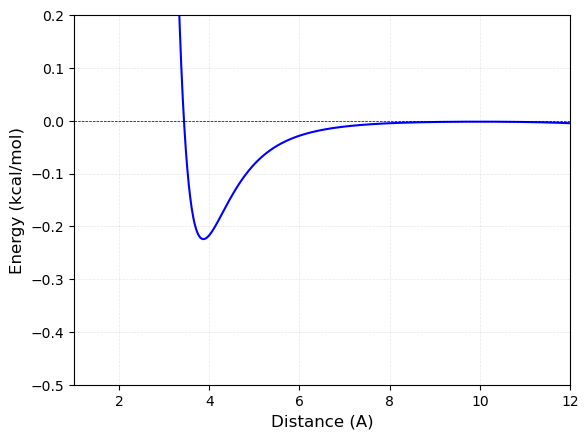

In [71]:
fig, ax = plt.subplots()

ax.plot(np.linspace(1, 12, 1000), energy_list / (kcal/mol), label='GNP Potential', color='blue')

ax.set_xlim(1, 12)

ax.set_ylim(-0.5, 0.2)

ax.set_xlabel('Distance (A)', fontsize=12)
ax.set_ylabel('Energy (kcal/mol)', fontsize=12)

ax.axhline(0, color='black', lw=0.5, ls='--')

ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.3)